# 1. Install necessary Libraries
**Experiment: Exp 1: Baseline CE Loss + 3-Stage Fine-Tuning (No Freezing)**

Baseline experiment using standard Cross-Entropy loss with 3-stage learning rate schedule but NO backbone freezing. All parameters are trainable from the start.

In this part, we'll begin by installing necessary libraries needed for running our computer vision training and testing scripts\
**(NOTE): NO NEED TO RERUN THIS CELL EVEN IF SERVER RESTARTS**, as the libraries are stored inside VM boot disk and will not be removed

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install transformers scikit-learn pillow pandas numpy matplotlib huggingface_hub ipywidgets opencv-python google-cloud-storage

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# 2. Download Dataset From Storage Bucket to Jupyter Server
This is to reduce continuous Read/Write Call from Storage Bucket and reduce cost.\
**(Note): RUN THIS CELL ONCE ONLY EVEN IF SERVER RESTARTS.** This is because the dataset is stored locally in Jupyter Server and will remain even if server restart.\
Running multiple times may result in the 4939 images downloaded multiple times

In [2]:
from google.cloud import storage
import os

client = storage.Client()
bucket = client.bucket('naic-dataset-images')

# 1. Create the local directory
os.makedirs('dataset/image', exist_ok=True)

# 2. Download labels.csv permanently to the local disk
print("Fetching labels.csv...")
blob_csv = bucket.blob('labels.csv')
# Save it locally instead of holding it in memory
blob_csv.download_to_filename('dataset/labels.csv')
print("✅ labels.csv saved to dataset/labels.csv")

# 3. Download the images
blobs = bucket.list_blobs(prefix='image/')
print("\nStarting image download...")

download_count = 0
for i, blob in enumerate(blobs):
    if not blob.name.endswith('/'):
        filename = blob.name.split('/')[-1]
        local_path = f'dataset/image/{filename}'

        # Only download if the file isn't already on the disk
        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
            download_count += 1

    if i % 500 == 0:
        print(f"Scanned {i} files...")

print(f"✅ Download complete! Fetched {download_count} new images. L4 GPU is ready to work.")

Fetching labels.csv...
✅ labels.csv saved to dataset/labels.csv

Starting image download...
Scanned 0 files...
Scanned 500 files...
Scanned 1000 files...
Scanned 1500 files...
Scanned 2000 files...
Scanned 2500 files...
Scanned 3000 files...
Scanned 3500 files...
Scanned 4000 files...
Scanned 4500 files...
✅ Download complete! Fetched 0 new images. L4 GPU is ready to work.


# 3. Read CSV File from Storage Bucket
In this part, since we need to create a variable df using pandas to load the csv file, we should separate this part from downloading part as variable is voilatile and will be reset every time kernel/server restarts

In [3]:
import pandas as pd

# Read the CSV directly from the VM's high-speed local disk
df = pd.read_csv('dataset/labels.csv')

print(f"Ready to train with {len(df)} images on local disk.")

Ready to train with 4939 images on local disk.


# 4. CLAHE Data Preprocessing + Retina Cropping
In this part, we'll write Contrast Limited Adaptive Histogram Equalization (CLAHE) preprocessing function logic, which is used to enhance the blurry dataset images to enable clearer image and allow small pixels to be detected. Besides that, we also implemented retina cropping to determine the eye fundus pixels more accurately

In [4]:
import cv2
import numpy as np
from PIL import Image

def crop_fundus(image, tol=10):
    """
    Removes the useless black borders around the circular fundus image.
    tol: Tolerance for black pixels (values below 10 are considered background).
    """
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale to easily separate the eye from the background
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Create a mask of all pixels brighter than the tolerance
    mask = gray > tol

    # Get the coordinates of the actual eyeball
    coords = np.argwhere(mask)

    # Safety check: if the image is completely black, return the original
    if coords.size == 0:
        return image

    # Find the bounding box (min and max Y, min and max X)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1 # +1 to include the last pixel

    # Crop the image using numpy slicing
    cropped = image[y0:y1, x0:x1]

    return cropped

def preprocess_fundus(image):
    """
    The ultimate medical preprocessing pipeline.
    1. Tight crop the retina.
    2. Apply Green Channel CLAHE.
    """
    # Step 1: Remove black borders
    cropped_img = crop_fundus(image)

    # Step 2: Split into R, G, B channels
    r, g, b = cv2.split(cropped_img)

    # Step 3: Apply Green Channel CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_enhanced = clahe.apply(g)

    # Step 4: Merge and return as PIL Image for PyTorch
    enhanced = cv2.merge((r, g_enhanced, b))
    return Image.fromarray(enhanced)

# 5. Preprocessed vs Processed Image Visualization Comparison
In this part, we'll run a script to compare the dataset images before and after preprocessing to see if it's successful and fulfills our requirements

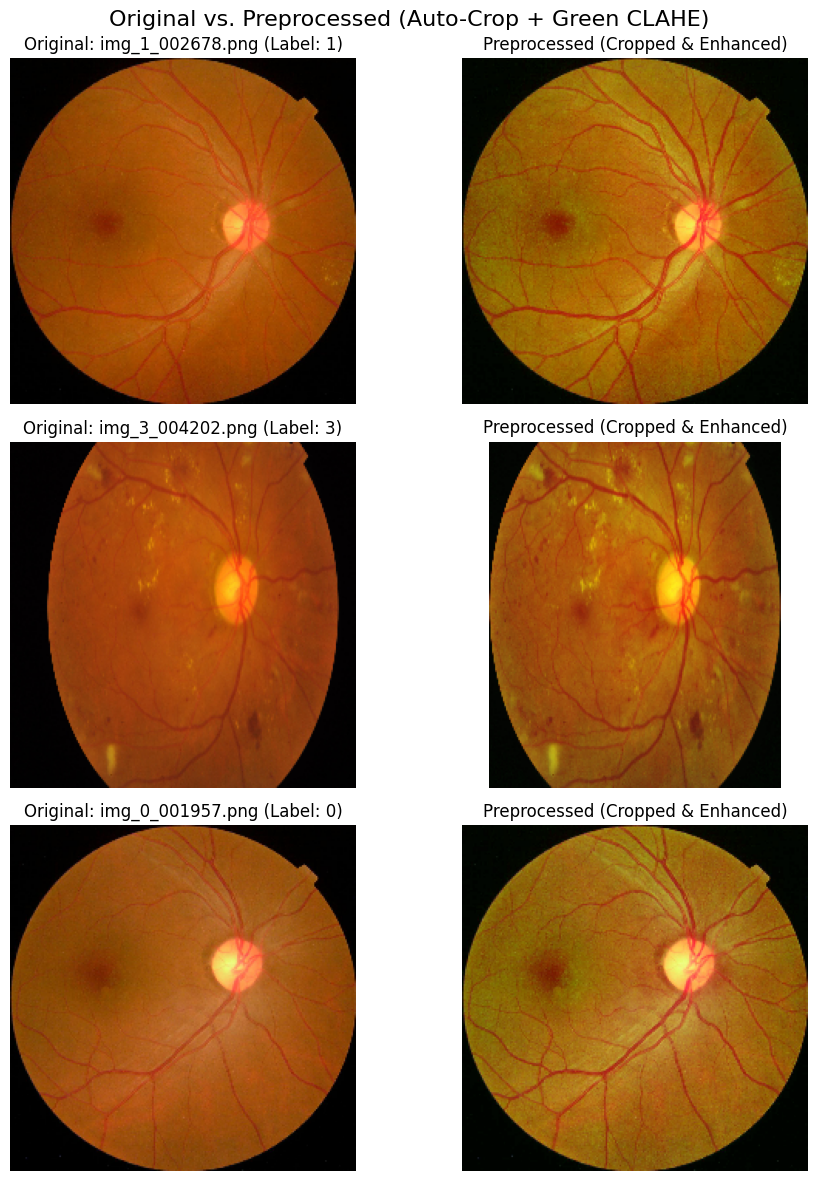

In [5]:
import matplotlib.pyplot as plt

def display_preprocessing_samples(dataframe, img_directory, num_samples=3):
    """
    Randomly samples images from the dataframe and displays a side-by-side
    comparison of the original vs. preprocessed images.
    """
    # Take random samples from the dataframe
    samples = dataframe.sample(n=num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle("Original vs. Preprocessed (Auto-Crop + Green CLAHE)", fontsize=16)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_directory, row['Image'])
        original_img = Image.open(img_path).convert("RGB")

        # Apply the medical preprocessing pipeline
        preprocessed_img = preprocess_fundus(original_img)

        # Plot Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {row['Image']} (Label: {row['Label']})")
        axes[i, 0].axis('off')

        # Plot Preprocessed
        axes[i, 1].imshow(preprocessed_img)
        axes[i, 1].set_title(f"Preprocessed (Cropped & Enhanced)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer (Ensure 'df' and 'dataset/image' are defined in your environment)
display_preprocessing_samples(df, "dataset/image/", num_samples=3)

# 6. Custom Dataset Loader
Since we're using a custom dataset, we will need to write a custom dataset loader to pass our image data to the model


In [6]:
from torch.utils.data import Dataset
from PIL import Image
import os

class MedicalDatasetLoader(Dataset):
    def __init__(self, df, img_dir, transform=None, use_preprocessing=True):
        self.data = df # Differentiate between train_df, val_df and test_df
        self.img_dir = img_dir # Image Directory Path
        self.transform = transform # Data augmentation
        self.use_preprocessing = use_preprocessing # Apply cropping & CLAHE

    def __len__(self):
        return len(self.data) # Calculate the number of rows of the dataset

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['Image'] # Get the image name from the csv header
        label = int(self.data.iloc[idx]['Label']) # Get the Label value from csv header

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # 🔥 Call the combined auto-crop and green CLAHE pipeline
        if self.use_preprocessing:
            image = preprocess_fundus(image)

        if self.transform: # Implement Data Augmentation (Resize, Flip, etc.)
            image = self.transform(image)

        return image, label

# 7. Setup Cuda Device
Here in this part, we check if PyTorch detects our GPU cuda cores

In [7]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if cuda is detected by pytorch, fallback to CPU otherwise
print("Cuda available: ", torch.cuda.is_available())

Cuda available:  True


# 8. Setup Model
In this part, we will load the Deep Learning model from huggingface. Remember to change the library imports and pretrain name based on your designated model choice.\
Feel free to design the inner architecture of your model choice such as its layers, activation function types and Feed Forward Network (FFN) layers here as well

In [8]:
from transformers import AutoImageProcessor, EfficientNetForImageClassification

# 1. Define the model variant
model_name = 'google/efficientnet-b3'

# 2. Load EfficientNetB3 with the built-in classification head
# We set num_labels=5 for your retinopathy severity classes
model = EfficientNetForImageClassification.from_pretrained(
    model_name,
    num_labels=5,
    ignore_mismatched_sizes=True # Essential when replacing the ImageNet head with 5 classes
).to(device)

# 3. Load the processor for normalization values
processor = AutoImageProcessor.from_pretrained(model_name)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/574 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b3
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1536]) vs model:torch.Size([5, 1536])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


# 9. Data Preprocessing
In this part, we will perform data augmentation on our dataset through torchvision library, then split our dataset into training and validation data.

In [9]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std) # We use the model's custom normalization values
])

val_transform = transforms.Compose([ # No data augmentation for val/testing
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Step 1: Train+Val / Test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

test_dataset = MedicalDatasetLoader(test_df, "dataset/image", val_transform, use_preprocessing=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=16, # Adjust this according to the L4 GPU VRAM usage
    shuffle=False,
)
print(f"Test: {len(test_df)}")

Test: 988


# 10. Experiment Logging Class
In this part, we'll create a log class tha can help us to logs our hyperparameter lists as well as result metrics.

In [10]:
import json
from datetime import datetime
import os

class ExperimentTracker:
    def __init__(self, base_dir="experiments"):
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.exp_dir = os.path.join(base_dir, f"exp_{timestamp}")
        os.makedirs(self.exp_dir)

        self.epoch_metrics = []
        self.final_metrics = {}
        self.config = {}

    # ---------------- CONFIG ----------------
    def log_config(self, config):
        self.config = config
        with open(os.path.join(self.exp_dir, "config.json"), "w") as f:
            json.dump(config, f, indent=4)

    # 🔥 NEW: Saves state for Spot Instance recovery
    def save_checkpoint(self, fold, epoch, model, optimizer, scheduler, scaler, is_best=False):
        checkpoint = {
            'fold': fold,
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }
        # Save 'latest' for recovery
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        torch.save(checkpoint, ckpt_path)

        if is_best:
            torch.save(model.state_dict(), os.path.join(self.exp_dir, f"best_model_fold_{fold}.pth"))
        print(f"💾 Checkpoint saved at Epoch {epoch+1}")

    # 🔥 NEW: Loads state if the script restarts
    def load_checkpoint(self, fold, model, optimizer, scheduler, scaler):
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        if os.path.exists(ckpt_path):
            print(f"🔄 Resuming from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path)
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            return ckpt['epoch'] + 1 # Start from the next epoch
        return 0

    # ---------------- PER EPOCH ----------------
    def log_epoch(self, epoch, train_loss, val_loss, train_acc, val_acc, current_lr):
        self.epoch_metrics.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "learning_rate": current_lr # 🔥 NEW: Logs the exact LR for this epoch
        })

    # ---------------- FINAL METRICS ----------------
    def log_final_metrics(self, split, acc, prec, rec, f1, roc_auc, cm):
        if "final_metrics" not in self.__dict__ or not isinstance(self.final_metrics, dict):
            self.final_metrics = {}

        self.final_metrics[split] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc_score": roc_auc,
            "confusion_matrix": cm.tolist()
        }

    # ---------------- SAVE ----------------
    def save_all(self):
        with open(os.path.join(self.exp_dir, "metrics.json"), "w") as f:
            json.dump({
                "config": self.config,
                "epoch_metrics": self.epoch_metrics,
                "final_metrics": self.final_metrics
            }, f, indent=4)

    def save_model(self, model, name="best_model.pth"):
        torch.save(model.state_dict(), os.path.join(self.exp_dir, name))

# Training Script & Hyperparameter Tuning
Three-stage fine-tuning with stratified 5-fold cross validation, WeightedRandomSampler, mixed precision training, and early stopping.

In [11]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler
from torch.amp import autocast
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, DataLoader
from transformers import EfficientNetForImageClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

early_stopping_patience = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

HYPERPARAMS_CONFIG = {
    "model_name": "google/efficientnet-b3",
    "learning_rate_base": 5e-6,
    "weight_decay": 1e-4,
    "eta_min_base": 1e-6,
    "epochs": 20,
    "batch_size": 32,
    "label_smoothing": 0.1,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
}
tracker = ExperimentTracker()
tracker.log_config(HYPERPARAMS_CONFIG)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df["Label"])):
    epochs_no_improvement = 0
    best_val_loss = float('inf')

    print(f"\n🔥 Fold {fold+1}")
    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

# ---------------- WEIGHTED RANDOM SAMPLER ----------------
    # Dynamically calculate weights based on THIS specific fold's training split
    class_counts = train_df['Label'].value_counts().sort_index().values
    sampler_weights = 1. / class_counts
    
    # Map the weight to every single sample in the training dataframe
    sample_weights = np.array([sampler_weights[t] for t in train_df['Label']])
    sample_weights = torch.from_numpy(sample_weights).double()

    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    # ---------------- DATASETS & LOADERS ----------------
    train_dataset = MedicalDatasetLoader(train_df, "dataset/image/", train_transform, use_preprocessing=True)
    val_dataset = MedicalDatasetLoader(val_df, "dataset/image/", val_transform, use_preprocessing=False)

    train_loader = DataLoader(train_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], sampler=sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

    print(f"Train: {len(train_df)}, Val: {len(val_df)}")

    # ---------------- INITIALIZE EfficientNetB3 CORRECTLY ----------------
    model = EfficientNetForImageClassification.from_pretrained(
        HYPERPARAMS_CONFIG["model_name"],
        num_labels=5,
        ignore_mismatched_sizes=True
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=HYPERPARAMS_CONFIG["learning_rate_base"], weight_decay=HYPERPARAMS_CONFIG["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"], eta_min=HYPERPARAMS_CONFIG['eta_min_base'])
    scaler = GradScaler()

    start_epoch = tracker.load_checkpoint(fold, model, optimizer, scheduler, scaler)

    # ---------------- LOSS FUNCTION ----------------
    # 🔥 FIX: Remove class_weights. The Sampler already balances the data.
    # We keep label_smoothing=0.1 to prevent overconfidence.
    criterion = nn.CrossEntropyLoss(weight=None, label_smoothing=0.1)

    # No backbone freezing - all parameters trainable from the start
    print("🔓 All parameters are trainable (no backbone freezing)")

    # ---------------- TRAINING LOOP ----------------
    for epoch in range(start_epoch, HYPERPARAMS_CONFIG["epochs"]):

        # ---------------- TRAINING ----------------
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(pixel_values=inputs).logits
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast(device_type='cuda'):
                    outputs = model(pixel_values=inputs).logits
                    loss = criterion(outputs, labels)
                probs = F.softmax(outputs, dim=1)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += inputs.size(0)
                val_correct += (predicted == labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # ---------------- METRICS ----------------
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        tracker.log_epoch(epoch, epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc, current_lr)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improvement = 0
            tracker.save_model(model, name=f"best_model_fold_{fold}.pth")
        else:
            epochs_no_improvement += 1
            if epochs_no_improvement >= early_stopping_patience:
                print('Early stopping triggered!')
                break

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro')
        cm = confusion_matrix(all_labels, all_preds)

        try:
            roc_auc = roc_auc_score(np.array(all_labels), np.array(all_probs), multi_class='ovr')
        except ValueError:
            roc_auc = 0.0
        print(f"=======================================================================")
        print(f"Epoch [{epoch+1}/{HYPERPARAMS_CONFIG['epochs']}] | LR: {current_lr:.2e}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        print(f"Metrics:\n Precision: {prec},\nRecall: {rec},\nF1:{f1}")
        print(f"=======================================================================")

    tracker.log_final_metrics(f"validation_fold_{fold + 1}", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()



🔥 Fold 1
Train: 3160, Val: 791


You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/574 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b3
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1536]) vs model:torch.Size([5, 1536])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


🔓 All parameters are trainable (no backbone freezing)
Epoch [1/20] | LR: 5.00e-06
Train Loss: 1.6110 | Train Acc: 0.2275
Val Loss: 1.5265 | Val Acc: 0.4172
Metrics:
 Precision: 0.34714859611427284,
Recall: 0.3251774818070083,
F1:0.28854690748492107
Epoch [2/20] | LR: 4.98e-06
Train Loss: 1.5406 | Train Acc: 0.3430
Val Loss: 1.4845 | Val Acc: 0.4652
Metrics:
 Precision: 0.39477516404838725,
Recall: 0.3772178214518047,
F1:0.3344306503867083
Epoch [3/20] | LR: 4.90e-06
Train Loss: 1.4816 | Train Acc: 0.4253
Val Loss: 1.3665 | Val Acc: 0.5360
Metrics:
 Precision: 0.37850096711798836,
Recall: 0.3861382432970176,
F1:0.3446281352497447
Epoch [4/20] | LR: 4.78e-06
Train Loss: 1.4310 | Train Acc: 0.4525
Val Loss: 1.3143 | Val Acc: 0.5575
Metrics:
 Precision: 0.42444125153689044,
Recall: 0.41505646728487944,
F1:0.37847559758741356
Epoch [5/20] | LR: 4.62e-06
Train Loss: 1.3645 | Train Acc: 0.5152
Val Loss: 1.3570 | Val Acc: 0.5297
Metrics:
 Precision: 0.3959649324277422,
Recall: 0.38607295562727

...

🔓 All parameters are trainable (no backbone freezing)
Epoch [1/20] | LR: 5.00e-06
Train Loss: 1.6172 | Train Acc: 0.2240
Val Loss: 1.5936 | Val Acc: 0.2228
Metrics:
 Precision: 0.3037676604258279,
Recall: 0.23091512496704744,
F1:0.19847791000989826
Epoch [2/20] | LR: 4.98e-06
Train Loss: 1.5440 | Train Acc: 0.3442
Val Loss: 1.5279 | Val Acc: 0.3696
Metrics:
 Precision: 0.36967758284164154,
Recall: 0.35311511798531187,
F1:0.3019743996212404
Epoch [3/20] | LR: 4.90e-06
Train Loss: 1.4681 | Train Acc: 0.4388
Val Loss: 1.4110 | Val Acc: 0.4937
Metrics:
 Precision: 0.38643312081225556,
Recall: 0.39211344758502165,
F1:0.36026374920263554
Epoch [4/20] | LR: 4.78e-06
Train Loss: 1.4074 | Train Acc: 0.4850
Val Loss: 1.3768 | Val Acc: 0.5063
Metrics:
 Precision: 0.38179445159284003,
Recall: 0.416248665344952,
F1:0.3736023100997969
Epoch [5/20] | LR: 4.62e-06
Train Loss: 1.3502 | Train Acc: 0.5220
Val Loss: 1.3612 | Val Acc: 0.5177
Metrics:
 Precision: 0.4020754403089871,
Recall: 0.43669546030702

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/574 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b3
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1536]) vs model:torch.Size([5, 1536])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


🔓 All parameters are trainable (no backbone freezing)
Epoch [1/20] | LR: 5.00e-06
Train Loss: 1.6116 | Train Acc: 0.2268
Val Loss: 1.5433 | Val Acc: 0.3633
Metrics:
 Precision: 0.2744819387853595,
Recall: 0.2860852004460286,
F1:0.26677178189538353
Epoch [2/20] | LR: 4.98e-06
Train Loss: 1.5274 | Train Acc: 0.3632
Val Loss: 1.4513 | Val Acc: 0.4696
Metrics:
 Precision: 0.3609725204180849,
Recall: 0.3706918779544478,
F1:0.33733695486170917
Epoch [3/20] | LR: 4.90e-06
Train Loss: 1.4621 | Train Acc: 0.4211
Val Loss: 1.3904 | Val Acc: 0.5430
Metrics:
 Precision: 0.40380025406061515,
Recall: 0.4304842034220936,
F1:0.40745378593902554
Epoch [4/20] | LR: 4.78e-06
Train Loss: 1.4021 | Train Acc: 0.4619
Val Loss: 1.3153 | Val Acc: 0.5671
Metrics:
 Precision: 0.4089146456880407,
Recall: 0.41554435267875955,
F1:0.39992800344562307
Epoch [5/20] | LR: 4.62e-06
Train Loss: 1.3602 | Train Acc: 0.4802
Val Loss: 1.2347 | Val Acc: 0.5848
Metrics:
 Precision: 0.46419799498746867,
Recall: 0.45080817601356

# Testing Script & Metrics Visualization
Evaluate the best model on the test set using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix.

In [12]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(pixel_values=inputs).logits
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ---------------- CALCULATING METRICS ----------------
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(
        np.array(all_labels),
        np.array(all_probs),
        multi_class='ovr'
    )
except ValueError:
    roc_auc = 0.0

tracker.log_final_metrics("test", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()

print("\n📊 TEST RESULTS")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall: {rec * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"ROC-AUC: {roc_auc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)



📊 TEST RESULTS
Accuracy: 68.22%
Precision: 55.05%
Recall: 54.04%
F1 Score: 53.44%
ROC-AUC: 87.34%
Confusion Matrix:
[[409  33   3   0   3]
 [ 17  61  18   1   8]
 [ 33  56 137  15  36]
 [  1   5  22   9   7]
 [ 19  10  26   1  58]]
